# FPCA + KNN Framework for Rheology Forecasting

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import splrep, splev
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import f1_score, recall_score, r2_score


In [2]:

DATA_PATH = "synthetic_battery_slurry_timeseries_dataset.csv"

LONG_FORMAT_COLUMNS = {
    "simulation_id",
    "time_frame",
    "viscosity_Pa_s",
}


def load_slurry_dataset(path):
    """Load either long-form slurry data or the older wide numeric format."""
    df = pd.read_csv(path)

    if LONG_FORMAT_COLUMNS.issubset(df.columns):
        df = df.sort_values(["simulation_id", "time_frame"])

        curves = df.pivot_table(
            index="simulation_id",
            columns="time_frame",
            values="viscosity_Pa_s",
            aggfunc="mean",
        ).sort_index(axis=1)

        curves = curves.interpolate(axis=1, limit_direction="both")
        curves = curves.fillna(curves.median(axis=0)).fillna(0.0)

        metadata_cols = [
            col for col in [
                "chemistry",
                "target_mu",
                "target_sigma",
                "relevant_range_label",
                "total_frames",
            ]
            if col in df.columns
        ]
        metadata = (
            df.groupby("simulation_id")[metadata_cols]
            .first()
            .reindex(curves.index)
        )

        return curves.to_numpy(dtype=float), curves.index.to_numpy(), metadata, curves.columns.to_numpy()

    numeric_df = df.select_dtypes(include=[np.number])
    if numeric_df.empty:
        raise ValueError("No numeric time-series columns found in the dataset.")

    return numeric_df.to_numpy(dtype=float), df.index.to_numpy(), pd.DataFrame(index=df.index), numeric_df.columns.to_numpy()


X_full, simulation_ids, metadata, frame_numbers = load_slurry_dataset(DATA_PATH)

print("X_full shape:", X_full.shape)
print("Number of simulations:", len(simulation_ids))
print("Frame range:", frame_numbers.min(), "to", frame_numbers.max())
display(metadata.head())


X_full shape: (2172, 1800)
Number of simulations: 2172
Frame range: 0 to 1799


,chemistry,target_mu,target_sigma,relevant_range_label,total_frames
simulation_id,,,,,
0,NMC-111,10.182208,1.056514,1,1552
1,NMC-111,13.744025,0.714604,1,1799
2,Graphite,3.919072,0.161342,1,1503
3,NMC-111,37.315201,2.298742,1,1730
4,NMC-111,27.098908,1.969366,1,1735


## Original Data Preview

,simulation_id,chemistry,time_frame,viscosity_Pa_s,target_mu,target_sigma,relevant_range_label,total_frames
0,0,NMC-111,0,45.955926,10.182208,1.056514,1,1552
1,0,NMC-111,1,46.107294,10.182208,1.056514,1,1552
2,0,NMC-111,2,46.136346,10.182208,1.056514,1,1552


,simulation_id,chemistry,time_frame,viscosity_Pa_s,target_mu,target_sigma,relevant_range_label,total_frames
0,0,NMC-111,0,45.955926,10.182208,1.056514,1,1552
1,0,NMC-111,1,46.107294,10.182208,1.056514,1,1552
2,0,NMC-111,2,46.136346,10.182208,1.056514,1,1552
3,0,NMC-111,3,45.737183,10.182208,1.056514,1,1552
4,0,NMC-111,4,45.791498,10.182208,1.056514,1,1552
5,0,NMC-111,5,45.603869,10.182208,1.056514,1,1552
6,0,NMC-111,6,45.498658,10.182208,1.056514,1,1552
7,0,NMC-111,7,45.271295,10.182208,1.056514,1,1552
8,0,NMC-111,8,45.111745,10.182208,1.056514,1,1552
9,0,NMC-111,9,45.053492,10.182208,1.056514,1,1552


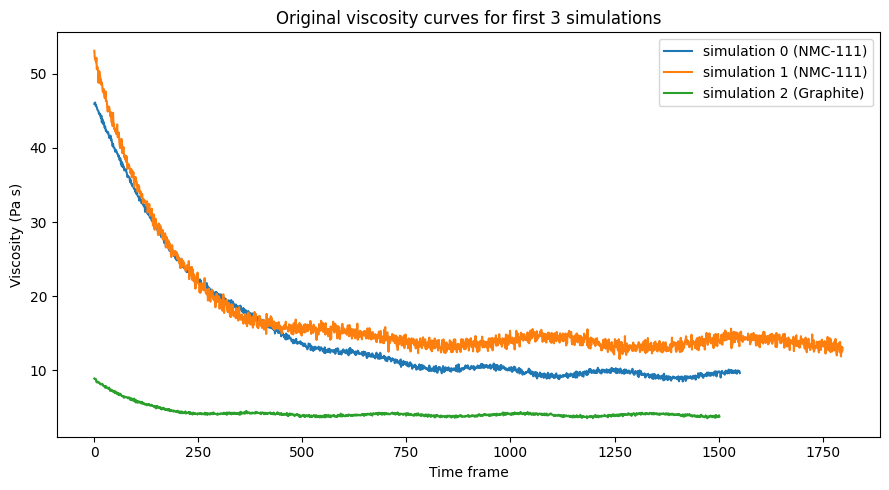

In [3]:

# Show the original CSV structure for the first 3 raw rows.
raw_preview = pd.read_csv(DATA_PATH, nrows=3)
display(raw_preview)

# Show how the first 3 simulations look after grouping by simulation_id.
raw_first_three = pd.read_csv(DATA_PATH)
first_three_ids = raw_first_three["simulation_id"].drop_duplicates().head(3).tolist()
first_three_simulations = raw_first_three[
    raw_first_three["simulation_id"].isin(first_three_ids)
].copy()

display(first_three_simulations.head(12))

plt.figure(figsize=(9, 5))
for sim_id in first_three_ids:
    sim_data = first_three_simulations[first_three_simulations["simulation_id"] == sim_id]
    chemistry = sim_data["chemistry"].iloc[0]
    plt.plot(
        sim_data["time_frame"],
        sim_data["viscosity_Pa_s"],
        linewidth=1.5,
        label=f"simulation {sim_id} ({chemistry})",
    )

plt.xlabel("Time frame")
plt.ylabel("Viscosity (Pa s)")
plt.title("Original viscosity curves for first 3 simulations")
plt.legend()
plt.tight_layout()
plt.show()


In [4]:

if {"target_mu", "target_sigma"}.issubset(metadata.columns):
    mu = metadata["target_mu"].astype(float).to_numpy()
    sigma = metadata["target_sigma"].astype(float).to_numpy()
else:
    last_1000 = X_full[:, -min(1000, X_full.shape[1]):]
    mu = np.mean(last_1000, axis=1)
    sigma = np.std(last_1000, axis=1)

if "relevant_range_label" in metadata.columns:
    y_class = metadata["relevant_range_label"].astype(int).to_numpy()
else:
    y_class = ((mu >= 0.1) & (mu <= 50)).astype(int)

y_reg = np.column_stack([
    mu - sigma,
    mu + sigma,
])

print("Class counts:")
print(pd.Series(y_class).value_counts().sort_index())


Class counts:
0     347
1    1825
Name: count, dtype: int64


In [5]:

def smooth_curve(curve, spline_smoothing=0.5):

    x = np.arange(len(curve))

    tck = splrep(x, curve, k=3, s=spline_smoothing)

    smooth = splev(x, tck)

    return np.array(smooth)


def smooth_dataset(X, smoothing=0.5):

    return np.array([
        smooth_curve(curve, smoothing)
        for curve in X
    ])


## Screening Step

In [6]:

SCREEN_FRAMES = min(100, X_full.shape[1])

X_screen = X_full[:, :SCREEN_FRAMES]

X_screen_smooth = smooth_dataset(X_screen)

pca_screen = PCA(n_components=min(10, X_screen_smooth.shape[0], X_screen_smooth.shape[1]))

X_screen_fpca = pca_screen.fit_transform(X_screen_smooth)

stratify_screen = y_class if pd.Series(y_class).value_counts().min() >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    X_screen_fpca,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=stratify_screen
)

screen_neighbors = [k for k in [5, 7, 11, 15, 21, 28] if k <= len(X_train)]

param_grid = {
    "n_neighbors": screen_neighbors,
    "metric": ["manhattan", "minkowski"]
}

cv_clf = min(5, pd.Series(y_train).value_counts().min())

grid_clf = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=cv_clf,
    scoring="f1"
)

grid_clf.fit(X_train, y_train)

best_clf = grid_clf.best_estimator_

y_pred = best_clf.predict(X_test)

print("Best Parameters:", grid_clf.best_params_)
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))


c:\Users\priti\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\interpolate\_fitpack_py.py:307: RuntimeWarning: The maximal number of iterations (20) allowed for finding smoothing
spline with fp=s has been reached. Probable cause: s too small.
(abs(fp-s)/s>0.001)
  res = _impl.splrep(x, y, w, xb, xe, k, task, s, t, full_output, per, quiet)
c:\Users\priti\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\interpolate\_fitpack_py.py:307: RuntimeWarning: A theoretically impossible result when finding a smoothing spline
with fp = s. Probable cause: s too small. (abs(fp-s)/s>0.001)
  res = _impl.splrep(x, y, w, xb, xe, k, task, s, t, full_output, per, quiet)


Best Parameters: {'metric': 'manhattan', 'n_neighbors': 11}
F1 Score: 0.9641434262948207
Recall: 0.9918032786885246


## Pooled Forecasting Step

In [7]:

FORECAST_FRAMES = min(150, X_full.shape[1])

relevant_idx = np.where(y_class == 1)[0]

X_forecast = X_full[relevant_idx, :FORECAST_FRAMES]

y_forecast = y_reg[relevant_idx]

X_forecast_smooth = smooth_dataset(X_forecast)

pca_forecast = PCA(n_components=min(15, X_forecast_smooth.shape[0], X_forecast_smooth.shape[1]))

X_forecast_fpca = pca_forecast.fit_transform(X_forecast_smooth)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_forecast_fpca,
    y_forecast,
    test_size=0.2,
    random_state=42
)

forecast_neighbors = [k for k in [3, 5, 7, 9, 11] if k <= len(X_train_r)]

param_grid_reg = {
    "n_neighbors": forecast_neighbors,
    "metric": ["minkowski", "manhattan"]
}

cv_reg = min(5, len(X_train_r))

grid_reg = GridSearchCV(
    KNeighborsRegressor(),
    param_grid_reg,
    cv=cv_reg,
    scoring="r2"
)

grid_reg.fit(X_train_r, y_train_r)

best_reg = grid_reg.best_estimator_

y_pred_r = best_reg.predict(X_test_r)

print("Best Parameters:", grid_reg.best_params_)

print("R2 (mu-sigma):",
      r2_score(y_test_r[:,0], y_pred_r[:,0]))

print("R2 (mu+sigma):",
      r2_score(y_test_r[:,1], y_pred_r[:,1]))


c:\Users\priti\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\interpolate\_fitpack_py.py:307: RuntimeWarning: The maximal number of iterations (20) allowed for finding smoothing
spline with fp=s has been reached. Probable cause: s too small.
(abs(fp-s)/s>0.001)
  res = _impl.splrep(x, y, w, xb, xe, k, task, s, t, full_output, per, quiet)
c:\Users\priti\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\interpolate\_fitpack_py.py:307: RuntimeWarning: A theoretically impossible result when finding a smoothing spline
with fp = s. Probable cause: s too small. (abs(fp-s)/s>0.001)
  res = _impl.splrep(x, y, w, xb, xe, k, task, s, t, full_output, per, quiet)


Best Parameters: {'metric': 'manhattan', 'n_neighbors': 11}
R2 (mu-sigma): 0.8145363033029085
R2 (mu+sigma): 0.845857115776477


In [8]:

print("The old pooled regression plot has been replaced.")
print("Run the Material-wise Forecasting Step cell and then the Material-wise Prediction Plots cell to get the 6-panel graph.")


The old pooled regression plot has been replaced.
Run the Material-wise Forecasting Step cell and then the Material-wise Prediction Plots cell to get the 6-panel graph.


## Material-wise Forecasting Step

In [9]:

def train_screening_model(indices, label):
    indices = np.asarray(indices)
    X_subset = X_full[indices, :SCREEN_FRAMES]
    y_subset = y_class[indices]

    class_counts = pd.Series(y_subset).value_counts()
    if len(class_counts) < 2 or class_counts.min() < 2:
        return None, {
            "chemistry": label,
            "screening_status": "skipped: needs at least two classes with two samples each",
        }

    X_smooth = smooth_dataset(X_subset)
    pca = PCA(n_components=min(10, X_smooth.shape[0], X_smooth.shape[1]))
    X_fpca = pca.fit_transform(X_smooth)

    X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
        X_fpca,
        y_subset,
        test_size=0.2,
        random_state=42,
        stratify=y_subset,
    )

    neighbors = [k for k in [5, 7, 11, 15, 21, 28] if k <= len(X_train_m)]
    cv = min(5, pd.Series(y_train_m).value_counts().min())

    grid = GridSearchCV(
        KNeighborsClassifier(),
        {"n_neighbors": neighbors, "metric": ["manhattan", "minkowski"]},
        cv=cv,
        scoring="f1",
    )
    grid.fit(X_train_m, y_train_m)

    pred = grid.best_estimator_.predict(X_test_m)
    metrics = {
        "chemistry": label,
        "n_total": len(indices),
        "n_irrelevant": int((y_subset == 0).sum()),
        "n_relevant": int((y_subset == 1).sum()),
        "screening_best_params": grid.best_params_,
        "screening_f1": f1_score(y_test_m, pred, zero_division=0),
        "screening_recall": recall_score(y_test_m, pred, zero_division=0),
        "screening_status": "trained",
    }

    model = {
        "pca_screen": pca,
        "classifier": grid.best_estimator_,
    }
    return model, metrics


def train_forecasting_model(indices, label):
    indices = np.asarray(indices)
    relevant_subset = indices[y_class[indices] == 1]

    if len(relevant_subset) < 10:
        return None, {
            "chemistry": label,
            "forecast_status": "skipped: needs at least 10 relevant simulations",
        }, pd.DataFrame()

    X_subset = X_full[relevant_subset, :FORECAST_FRAMES]
    y_subset = y_reg[relevant_subset]

    X_smooth = smooth_dataset(X_subset)
    pca = PCA(n_components=min(15, X_smooth.shape[0], X_smooth.shape[1]))
    X_fpca = pca.fit_transform(X_smooth)

    X_train_m, X_test_m, y_train_m, y_test_m, id_train_m, id_test_m = train_test_split(
        X_fpca,
        y_subset,
        simulation_ids[relevant_subset],
        test_size=0.2,
        random_state=42,
    )

    neighbors = [k for k in [3, 5, 7, 9, 11] if k <= len(X_train_m)]
    cv = min(5, len(X_train_m))

    grid = GridSearchCV(
        KNeighborsRegressor(),
        {"n_neighbors": neighbors, "metric": ["minkowski", "manhattan"]},
        cv=cv,
        scoring="r2",
    )
    grid.fit(X_train_m, y_train_m)

    pred = grid.best_estimator_.predict(X_test_m)

    metrics = {
        "chemistry": label,
        "forecast_relevant_samples": len(relevant_subset),
        "forecast_best_params": grid.best_params_,
        "r2_mu_minus_sigma": r2_score(y_test_m[:, 0], pred[:, 0]),
        "r2_mu_plus_sigma": r2_score(y_test_m[:, 1], pred[:, 1]),
        "forecast_status": "trained",
    }

    predictions = pd.DataFrame({
        "simulation_id": id_test_m,
        "chemistry": label,
        "true_mu_minus_sigma": y_test_m[:, 0],
        "pred_mu_minus_sigma": pred[:, 0],
        "true_mu_plus_sigma": y_test_m[:, 1],
        "pred_mu_plus_sigma": pred[:, 1],
    })

    model = {
        "pca_forecast": pca,
        "regressor": grid.best_estimator_,
    }
    return model, metrics, predictions


material_models = {}
material_results = []
material_prediction_tables = []

if "chemistry" in metadata.columns:
    for chemistry in sorted(metadata["chemistry"].dropna().unique()):
        material_idx = np.where(metadata["chemistry"].to_numpy() == chemistry)[0]

        screen_model, screen_metrics = train_screening_model(material_idx, chemistry)
        forecast_model, forecast_metrics, forecast_predictions = train_forecasting_model(material_idx, chemistry)

        material_models[chemistry] = {
            "screening": screen_model,
            "forecasting": forecast_model,
        }
        material_results.append({**screen_metrics, **forecast_metrics})
        if not forecast_predictions.empty:
            material_prediction_tables.append(forecast_predictions)

    material_results_df = pd.DataFrame(material_results)
    material_forecast_predictions = pd.concat(material_prediction_tables, ignore_index=True)
    material_forecast_predictions_by_chemistry = {
        chemistry: table.reset_index(drop=True)
        for chemistry, table in material_forecast_predictions.groupby("chemistry")
    }

    display(material_results_df)
    for chemistry, table in material_forecast_predictions_by_chemistry.items():
        print(f"\n{chemistry} forecast predictions")
        display(table.head())
else:
    print("No chemistry column found, so material-wise models were not trained.")


c:\Users\priti\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\interpolate\_fitpack_py.py:307: RuntimeWarning: The maximal number of iterations (20) allowed for finding smoothing
spline with fp=s has been reached. Probable cause: s too small.
(abs(fp-s)/s>0.001)
  res = _impl.splrep(x, y, w, xb, xe, k, task, s, t, full_output, per, quiet)
c:\Users\priti\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\interpolate\_fitpack_py.py:307: RuntimeWarning: The maximal number of iterations (20) allowed for finding smoothing
spline with fp=s has been reached. Probable cause: s too small.
(abs(fp-s)/s>0.001)
  res = _impl.splrep(x, y, w, xb, xe, k, task, s, t, full_output, per, quiet)
c:\Users\priti\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\interpolate\_fitpack_py.py:307: RuntimeWarning: The maximal number of iterations (20) allowed for finding smoothing
spline with fp=s has been reached. Probable cause: s too small.
(abs(fp-s)/s>0.001)
  res =

,chemistry,n_total,n_irrelevant,n_relevant,screening_best_params,screening_f1,screening_recall,screening_status,forecast_relevant_samples,forecast_best_params,r2_mu_minus_sigma,r2_mu_plus_sigma,forecast_status
0,Graphite,183,28,155,"{'metric': 'manhattan', 'n_neighbors': 5}",0.939394,1.000000,trained,155,"{'metric': 'minkowski', 'n_neighbors': 11}",0.860355,0.877992,trained
1,LFP,216,30,186,"{'metric': 'minkowski', 'n_neighbors': 7}",1.000000,1.000000,trained,186,"{'metric': 'manhattan', 'n_neighbors': 11}",0.598145,0.641304,trained
2,NMC-111,1773,289,1484,"{'metric': 'manhattan', 'n_neighbors': 11}",0.971993,0.993266,trained,1484,"{'metric': 'minkowski', 'n_neighbors': 11}",0.806581,0.828484,trained



Graphite forecast predictions


,simulation_id,chemistry,true_mu_minus_sigma,pred_mu_minus_sigma,true_mu_plus_sigma,pred_mu_plus_sigma
0,1002,Graphite,2.881275,2.856908,3.549377,3.296543
1,1972,Graphite,35.382984,35.018569,40.851383,43.245334
2,356,Graphite,27.976316,22.311500,33.385604,26.424802
3,310,Graphite,5.989685,9.581895,7.308254,10.825822
4,1637,Graphite,27.088338,24.346131,34.643146,29.075395



LFP forecast predictions


,simulation_id,chemistry,true_mu_minus_sigma,pred_mu_minus_sigma,true_mu_plus_sigma,pred_mu_plus_sigma
0,1412,LFP,2.161495,2.107406,2.333983,2.542078
1,1919,LFP,9.562865,8.510659,11.766724,10.004097
2,1987,LFP,25.711507,25.896393,30.687504,30.348237
3,1263,LFP,16.570441,24.018752,19.960980,28.097049
4,1256,LFP,6.066568,4.498735,6.577505,5.259784



NMC-111 forecast predictions


,simulation_id,chemistry,true_mu_minus_sigma,pred_mu_minus_sigma,true_mu_plus_sigma,pred_mu_plus_sigma
0,176,NMC-111,33.625529,27.045615,38.641275,32.100104
1,646,NMC-111,23.637157,25.576979,30.103873,31.528292
2,1507,NMC-111,33.925664,23.866503,41.250556,27.871472
3,800,NMC-111,30.950862,35.595908,38.344031,44.423995
4,2080,NMC-111,17.668011,13.854191,20.318380,16.351965


## Material-wise Prediction Plots

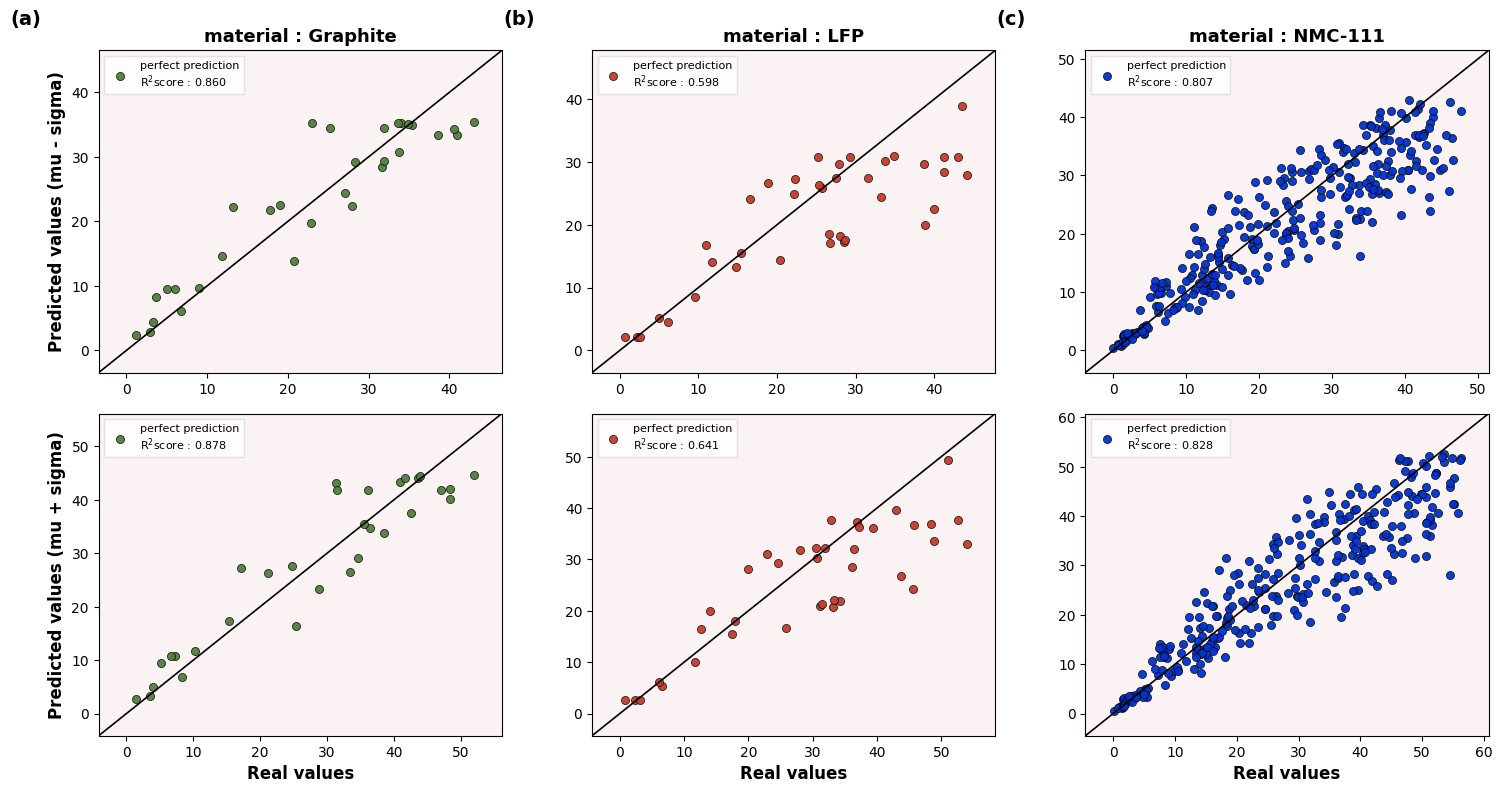

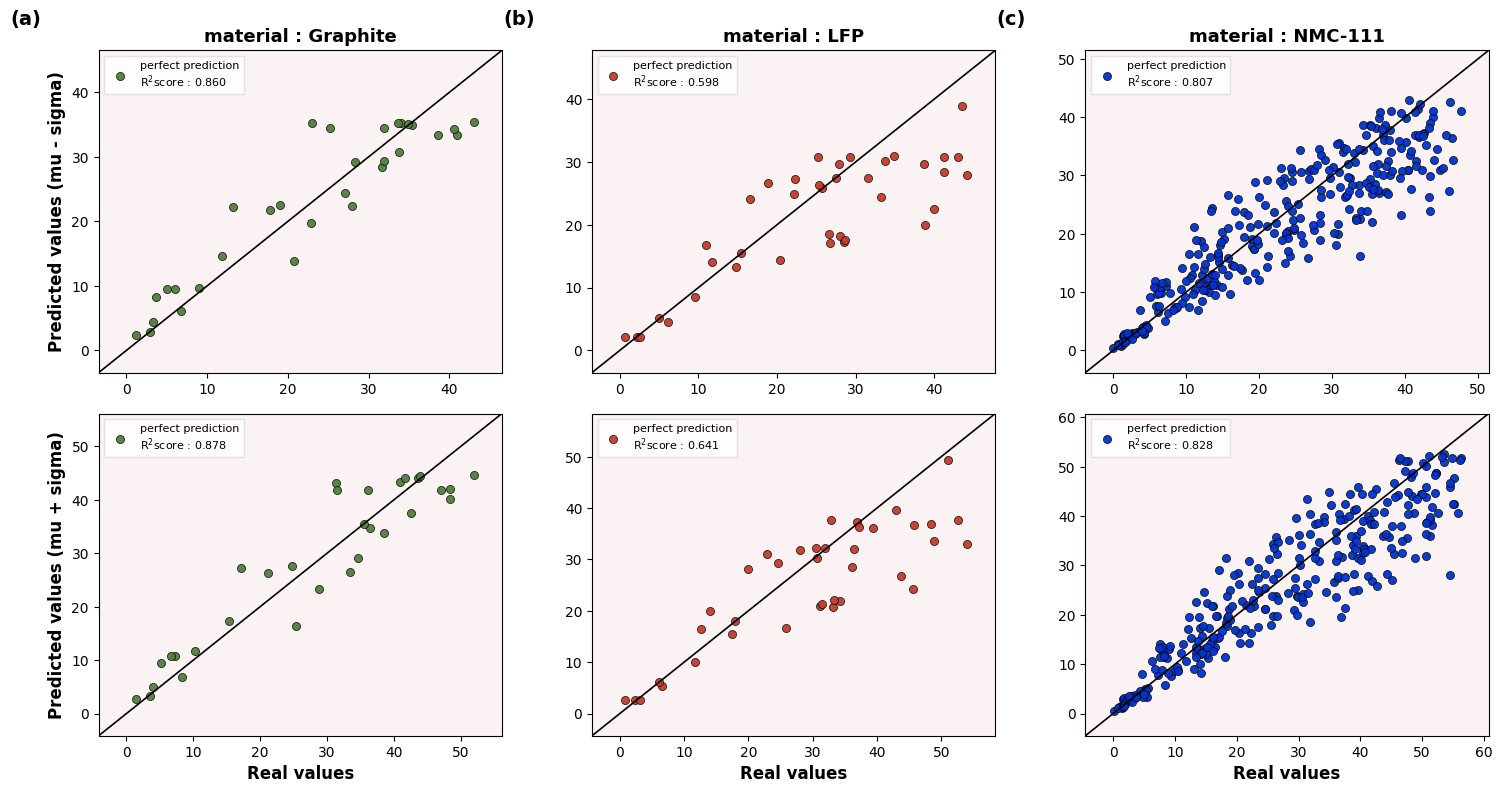

Saved material-wise forecast plot to material_wise_forecast_predictions.png


In [10]:

from IPython.display import display as notebook_display

if "material_forecast_predictions_by_chemistry" not in globals():
    raise RuntimeError("Run the Material-wise Forecasting Step cell before running this plot cell.")

material_order = [
    material for material in ["Graphite", "LFP", "NMC-111"]
    if material in material_forecast_predictions_by_chemistry
]
material_colors = {
    "Graphite": "#4f7f3b",
    "LFP": "#c43d2b",
    "NMC-111": "#0033cc",
}

if not material_order:
    raise RuntimeError("No material-wise forecast predictions found to plot.")

plt.close("all")
fig, axes = plt.subplots(2, len(material_order), figsize=(5 * len(material_order), 8), sharex=False, sharey=False)

if len(material_order) == 1:
    axes = np.array(axes).reshape(2, 1)

plot_specs = [
    ("true_mu_minus_sigma", "pred_mu_minus_sigma", "Predicted values (mu - sigma)"),
    ("true_mu_plus_sigma", "pred_mu_plus_sigma", "Predicted values (mu + sigma)"),
]

for col, material in enumerate(material_order):
    table = material_forecast_predictions_by_chemistry[material]

    for row, (true_col, pred_col, ylabel) in enumerate(plot_specs):
        ax = axes[row, col]
        true_values = table[true_col].to_numpy()
        pred_values = table[pred_col].to_numpy()
        r2 = r2_score(true_values, pred_values)

        axis_min = min(true_values.min(), pred_values.min(), 0)
        axis_max = max(true_values.max(), pred_values.max())
        padding = 0.08 * (axis_max - axis_min) if axis_max > axis_min else 1
        axis_min -= padding
        axis_max += padding

        ax.scatter(
            true_values,
            pred_values,
            s=34,
            color=material_colors.get(material, "#444444"),
            edgecolor="black",
            linewidth=0.5,
            alpha=0.95,
        )
        ax.plot([axis_min, axis_max], [axis_min, axis_max], color="black", linewidth=1.2, label="perfect prediction")

        ax.set_xlim(axis_min, axis_max)
        ax.set_ylim(axis_min, axis_max)
        ax.set_facecolor("#fbf3f3")
        ax.grid(False)

        if row == 0:
            ax.set_title(f"material : {material}", fontsize=13, fontweight="bold")

        if col == 0:
            ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")

        if row == 1:
            ax.set_xlabel("Real values", fontsize=12, fontweight="bold")

        ax.legend(
            [f"perfect prediction\nR$^2$score : {r2:.3f}"],
            loc="upper left",
            frameon=True,
            fancybox=False,
            edgecolor="#dddddd",
            fontsize=8,
        )

for label, ax in zip(["(a)", "(b)", "(c)"], axes[0]):
    ax.text(-0.22, 1.08, label, transform=ax.transAxes, fontsize=14, fontweight="bold")

fig.patch.set_facecolor("white")
fig.tight_layout()

OUTPUT_FIGURE_PATH = "material_wise_forecast_predictions.png"
fig.savefig(OUTPUT_FIGURE_PATH, dpi=300, bbox_inches="tight")

notebook_display(fig)
plt.show()
print(f"Saved material-wise forecast plot to {OUTPUT_FIGURE_PATH}")


## Prediction Helper

In [11]:

def predict_simulation(new_curve, chemistry=None):
    if isinstance(new_curve, pd.DataFrame):
        required = {"time_frame", "viscosity_Pa_s"}
        if not required.issubset(new_curve.columns):
            raise ValueError("DataFrame input must contain time_frame and viscosity_Pa_s columns.")

        new_curve = (
            new_curve.sort_values("time_frame")["viscosity_Pa_s"]
            .astype(float)
            .to_numpy()
        )
    else:
        new_curve = np.asarray(new_curve, dtype=float)

    if len(new_curve) < FORECAST_FRAMES:
        raise ValueError(f"Expected at least {FORECAST_FRAMES} frames, got {len(new_curve)}.")


    if chemistry is None:
        selected_screen_pca = pca_screen
        selected_classifier = best_clf
        selected_forecast_pca = pca_forecast
        selected_regressor = best_reg
        model_label = "pooled"
    else:
        if "material_models" not in globals() or chemistry not in material_models:
            available = sorted(material_models.keys()) if "material_models" in globals() else []
            raise ValueError(f"No material-wise model found for {chemistry}. Available: {available}")

        selected = material_models[chemistry]
        if selected["screening"] is None or selected["forecasting"] is None:
            raise ValueError(f"Material-wise model for {chemistry} was not trained.")

        selected_screen_pca = selected["screening"]["pca_screen"]
        selected_classifier = selected["screening"]["classifier"]
        selected_forecast_pca = selected["forecasting"]["pca_forecast"]
        selected_regressor = selected["forecasting"]["regressor"]
        model_label = chemistry

    screen_curve = smooth_curve(
        new_curve[:SCREEN_FRAMES]
    ).reshape(1, -1)

    screen_fpca = selected_screen_pca.transform(screen_curve)

    cls = selected_classifier.predict(screen_fpca)[0]

    if cls == 0:
        print(f"Simulation predicted as IRRELEVANT using {model_label} model")
        return

    print(f"Simulation predicted as RELEVANT using {model_label} model")

    forecast_curve = smooth_curve(
        new_curve[:FORECAST_FRAMES]
    ).reshape(1, -1)

    forecast_fpca = selected_forecast_pca.transform(forecast_curve)

    pred = selected_regressor.predict(forecast_fpca)[0]

    print("Predicted mu-sigma:", pred[0])
    print("Predicted mu+sigma:", pred[1])
